In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working! 🚀")

Everything is working! 🚀


In [2]:
df = pd.read_csv("../data/customer-churn-prediction.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
print(f"Number of Rows{df.shape[0]}")
print(f"Number of columns{df.shape[1]}")

Number of Rows7043
Number of columns21


In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#Exploratory Data Analysis(EDA)

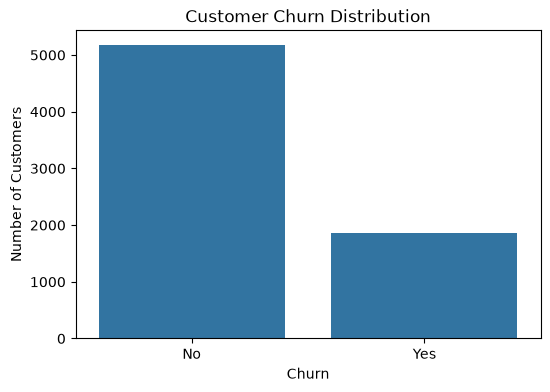

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()
plt.show()

In [11]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


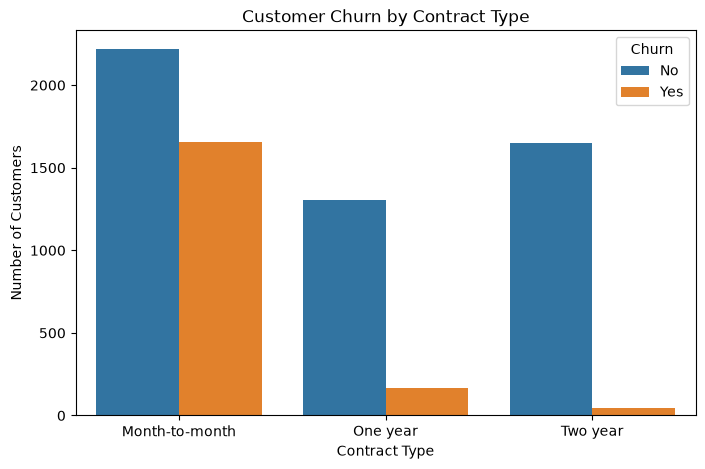

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

## Contract Type and Churn

### Observation

- Month-to-month customers have the highest churn rate.
- Churn decreases as the contract duration increases.
- Customers with longer-term contracts appear less likely to churn.

df.groupby['Churn']['Tenure].describe()

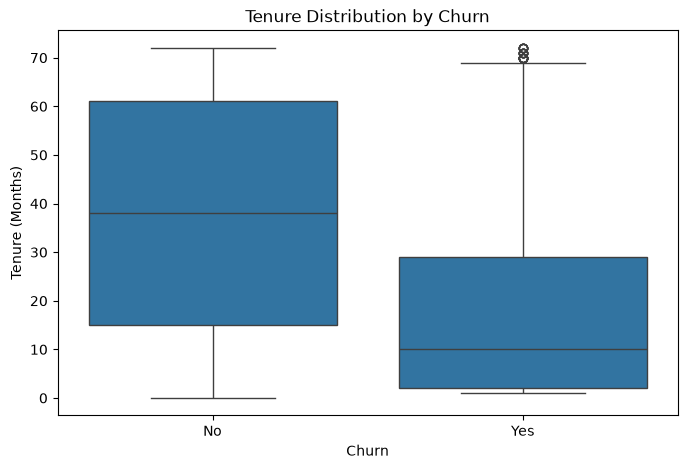

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## Tenure and Churn

### Observation

- Customers who churned have a lower average tenure than customers who stayed.
- Churned customers have an average tenure of approximately 18 months.
- Customers who stayed have an average tenure of approximately 38 months.
- Customers with shorter tenure appear more likely to churn.
- Churn appears to decrease as customer tenure increases.

### Business Interpretation

Newer customers may be more likely to leave, while customers who have been with the company longer appear more likely to remain.

In [14]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


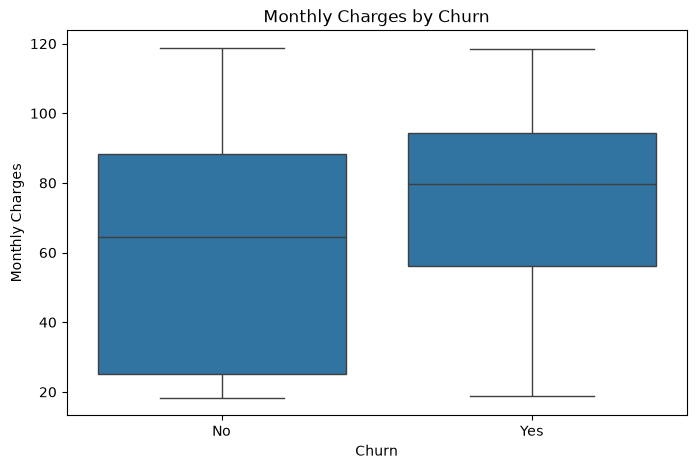

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [16]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


## Monthly Charges and Churn

### Observation

- The average monthly charge for churned customers is lower than for customers who stayed.
- Therefore, average monthly charges alone do not appear to explain customer churn.
- Further analysis is required to understand how MonthlyCharges interacts with other variables.

In [18]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


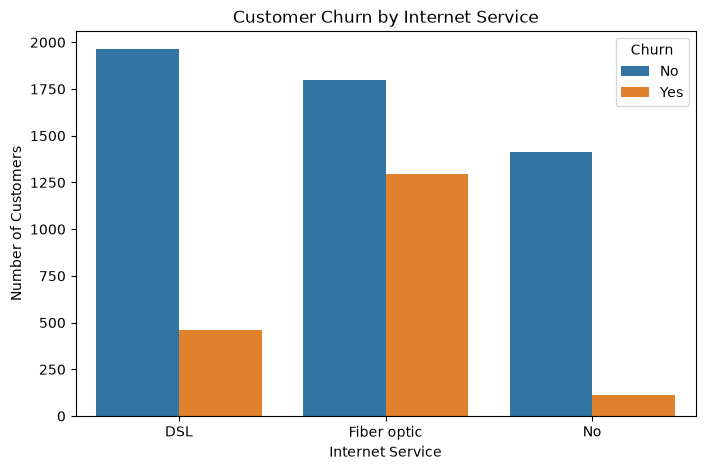

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
pd.crosstab(
    [df["InternetService"], df["Contract"]],
    df["Churn"],
    normalize="index"
).round(2)

Churn                             No   Yes
InternetService Contract                  
DSL             Month-to-month  0.68  0.32
                One year        0.91  0.09
                Two year        0.98  0.02
Fiber optic     Month-to-month  0.45  0.55
                One year        0.81  0.19
                Two year        0.93  0.07
No              Month-to-month  0.81  0.19
                One year        0.98  0.02
                Two year        0.99  0.01

## Internet Service, Contract Type and Churn

### Observation

- Fiber optic customers on month-to-month contracts have the highest churn rate at approximately 55%.
- DSL month-to-month customers have a churn rate of approximately 32%.
- Churn decreases as contract duration increases across all InternetService categories.
- Two-year contract customers have substantially lower churn rates than month-to-month customers.

### Business Interpretation

Month-to-month customers appear to be a high-risk customer segment, particularly those using fiber optic internet service.

This segment may require further investigation to understand the reasons behind the high churn rate.

In [21]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
).round(2)

Churn,No,Yes
OnlineSecurity,,
No,0.58,0.42
No internet service,0.93,0.07
Yes,0.85,0.15


In [22]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
).round(2)

Churn,No,Yes
TechSupport,,
No,0.58,0.42
No internet service,0.93,0.07
Yes,0.85,0.15


## Online Security and Tech Support

### Observation

- Churn rates differ between customers with and without OnlineSecurity.
- Churn rates also differ between customers with and without TechSupport.
- However, these variables should not be analysed in isolation.
- Contract type, tenure, InternetService and other customer characteristics may also influence the observed churn patterns.
- Further analysis is required before drawing a strong conclusion

In [23]:
high_risk = df[
    (df["InternetService"] == "Fiber optic") &
    (df["Contract"] == "Month-to-month")
]

pd.crosstab(
    high_risk["OnlineSecurity"],
    high_risk["Churn"],
    normalize="index"
).round(2)

Churn,No,Yes
OnlineSecurity,,
No,0.42,0.58
Yes,0.63,0.37


In [24]:
pd.crosstab(
    high_risk["TechSupport"],
    high_risk["Churn"],
    normalize="index"
).round(2)

Churn,No,Yes
TechSupport,,
No,0.42,0.58
Yes,0.61,0.39


## Online Security and Tech Support within Fiber Optic Customers

### Observation

- Among fiber optic customers, churn remains relatively high for customers with OnlineSecurity.
- Churn also remains relatively high among fiber optic customers with TechSupport.
- Therefore, having these services alone does not appear to eliminate the high churn pattern among fiber optic customers.
- Further analysis is required to understand the interaction between InternetService, Contract, tenure, and additional services.

In [25]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


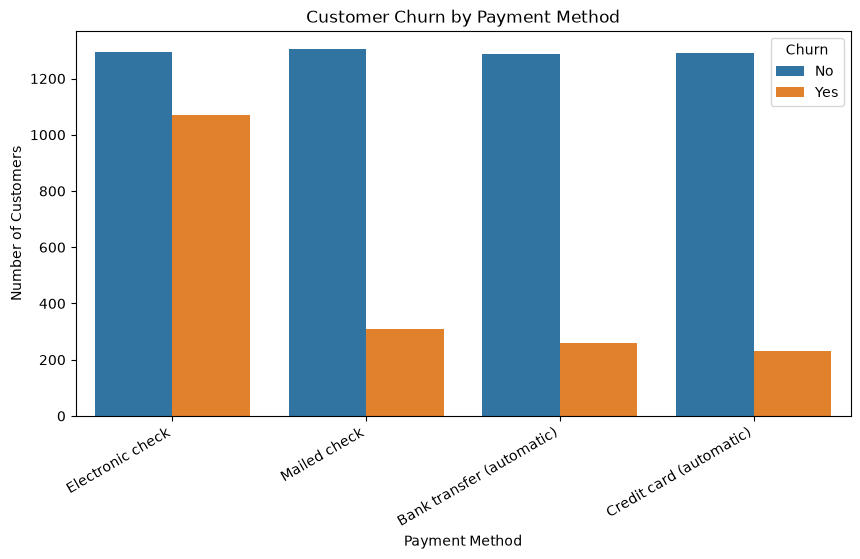

In [26]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")

plt.show()

In [27]:
pd.crosstab(
    df["PaymentMethod"],
    df["Contract"],
    normalize="index"
).round(2)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.38,0.25,0.37
Credit card (automatic),0.36,0.26,0.38
Electronic check,0.78,0.15,0.07
Mailed check,0.55,0.21,0.24


In [28]:
electronic_monthly = df[
    (df["PaymentMethod"] == "Electronic check") &
    (df["Contract"] == "Month-to-month")
]

electronic_monthly["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
Yes    53.73
No     46.27
Name: proportion, dtype: float64

In [29]:
pd.crosstab(
    df["PaymentMethod"],
    df["Contract"],
    values=df["Churn"].eq("Yes"),
    aggfunc="mean"
).mul(100).round(2)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),34.13,9.72,3.37
Credit card (automatic),32.78,10.30,2.24
Electronic check,53.73,18.44,7.74
Mailed check,31.58,6.82,0.79


## Payment Method + Contract Type and Churn

### Observation

- Customers using Electronic check with a month-to-month contract have a churn rate of approximately 53.73%.
- This is a high-risk customer segment in the dataset.
- The combination of payment method and contract type appears to be associated with higher customer churn.

### Business Interpretation

Customers with month-to-month contracts who use Electronic check may require additional attention from the customer retention team.

In [30]:
high_risk_group = df[
    (df["InternetService"] == "Fiber optic") &
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check")
]

high_risk_group["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
Yes    60.37
No     39.63
Name: proportion, dtype: float64

## High-Risk Customer Segment

### Observation

- Customers using Fiber optic internet, with a month-to-month contract and Electronic check payment method, have a churn rate of approximately 60.37%.
- This is one of the highest-risk customer segments identified during the exploratory analysis.

### Business Interpretation

This customer segment could be prioritised for further investigation and retention strategies.

However, this analysis shows an association and does not establish that these factors cause customers to churn.

In [31]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [32]:
df.isnull().sum().sum()

np.int64(0)

In [33]:
(df=="").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [35]:
df[df["TotalCharges"].str.strip() == ""].shape

(11, 21)

In [36]:
df[df["TotalCharges"].str.strip() == ""][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [37]:
df_clean = df.copy()

In [38]:
df_clean["TotalCharges"] = (
    df_clean["TotalCharges"]
    .str.strip()
    .replace("", "0")
)

In [39]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"]
)

In [40]:
df_clean["TotalCharges"].dtype

dtype('float64')

In [41]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

In [42]:
df_clean["TotalCharges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [43]:
df_clean["customerID"].duplicated().sum()

np.int64(0)

In [44]:
df_clean.duplicated().sum()

np.int64(0)

In [45]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [46]:
X = df_clean.drop(columns=["customerID", "Churn"])

In [47]:
y = df_clean["Churn"]

In [48]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [49]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [50]:
y.value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [51]:
y = y.map({"No": 0, "Yes": 1})

In [52]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [53]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [54]:

X.select_dtypes(include="str").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [55]:
X.select_dtypes(include="str").nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

In [56]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [57]:
categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

import warnings
warnings.filterwarnings('ignore')

print("Categorical Columns:")
print(categorical_cols)

print()

print("Numerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13124\474170354.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [58]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [59]:
X.head()

X.shape

(7043, 30)

In [60]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   PhoneService_Yes                       7043 non-null   bool   
 8   MultipleLines_No phone service         7043 non-null   bool   
 9   MultipleLines_Yes                      7043 non-null   bool   
 10  InternetService_Fiber optic            7043 non-null   bool   
 11  InternetService

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [62]:
print('X_train',X_train)

X_train       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
3738              0      35           49.20       1701.65         True   
3151              0      15           75.10       1151.55         True   
4860              0      13           40.55        590.35         True   
3867              0      26           73.50       1905.70        False   
3810              0       1           44.55         44.55         True   
...             ...     ...             ...           ...          ...   
6303              0      71          109.25       7707.70        False   
6227              0       2           46.05         80.35         True   
4673              1      25          102.80       2660.20        False   
2710              0      24           20.40        482.80        False   
5639              0       6           20.65        109.30         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3738        False           False             Fa

In [63]:

print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [64]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing set:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [66]:
X_train_scaled = scaler.fit_transform(X_train)

In [67]:
X_test_scaled = scaler.transform(X_test)

In [68]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 30)
(1409, 30)


In [69]:
from sklearn.linear_model import LogisticRegression

In [70]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [71]:
y_pred=logistic_model.predict(X_test_scaled)

In [72]:
print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [73]:
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test,y_pred)
print('accuracy:',accuracy)

accuracy: 0.8069552874378992


In [74]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test,y_pred)
print(cm)

[[925 110]
 [162 212]]


In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf_model=RandomForestClassifier(n_estimators=200, random_state=42)

In [78]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [79]:
rf_pred = rf_model.predict(X_test)

In [80]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [81]:
rf_cm=confusion_matrix(y_test,rf_pred)
print(rf_cm)

[[926 109]
 [183 191]]


In [82]:
from sklearn.metrics import roc_auc_score

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression ROC-AUC:", roc_auc_lr)
print("Random Forest ROC-AUC:", roc_auc_rf)

Logistic Regression ROC-AUC: 0.841778397788628
Random Forest ROC-AUC: 0.8264408793820558


In [83]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
10,InternetService_Fiber optic,0.776154
3,TotalCharges,0.514285
23,StreamingMovies_Yes,0.257227
21,StreamingTV_Yes,0.257144
9,MultipleLines_Yes,0.216167
26,PaperlessBilling_Yes,0.182034
28,PaymentMethod_Electronic check,0.181103
0,SeniorCitizen,0.053073
17,DeviceProtection_Yes,0.053048
29,PaymentMethod_Mailed check,0.032262


In [84]:
print("Top features associated with higher churn:")
display(coefficients.head(10))

print("Top features associated with lower churn:")
display(coefficients.tail(10))

Top features associated with higher churn:


,Feature,Coefficient
10,InternetService_Fiber optic,0.776154
3,TotalCharges,0.514285
23,StreamingMovies_Yes,0.257227
21,StreamingTV_Yes,0.257144
9,MultipleLines_Yes,0.216167
26,PaperlessBilling_Yes,0.182034
28,PaymentMethod_Electronic check,0.181103
0,SeniorCitizen,0.053073
17,DeviceProtection_Yes,0.053048
29,PaymentMethod_Mailed check,0.032262


Top features associated with lower churn:


,Feature,Coefficient
18,TechSupport_No internet service,-0.092761
16,DeviceProtection_No internet service,-0.092761
22,StreamingMovies_No internet service,-0.092761
19,TechSupport_Yes,-0.100502
6,Dependents_Yes,-0.103550
13,OnlineSecurity_Yes,-0.123561
24,Contract_One year,-0.285509
25,Contract_Two year,-0.586859
2,MonthlyCharges,-0.920153
1,tenure,-1.236528


In [85]:
coefficients["OddsRatio"] = np.exp(coefficients["Coefficient"])

coefficients.sort_values(
    by="OddsRatio",
    ascending=False
)

,Feature,Coefficient,OddsRatio
10,InternetService_Fiber optic,0.776154,2.173099
3,TotalCharges,0.514285,1.672442
23,StreamingMovies_Yes,0.257227,1.293338
21,StreamingTV_Yes,0.257144,1.293231
9,MultipleLines_Yes,0.216167,1.241310
26,PaperlessBilling_Yes,0.182034,1.199655
28,PaymentMethod_Electronic check,0.181103,1.198539
0,SeniorCitizen,0.053073,1.054507
17,DeviceProtection_Yes,0.053048,1.054480
29,PaymentMethod_Mailed check,0.032262,1.032788


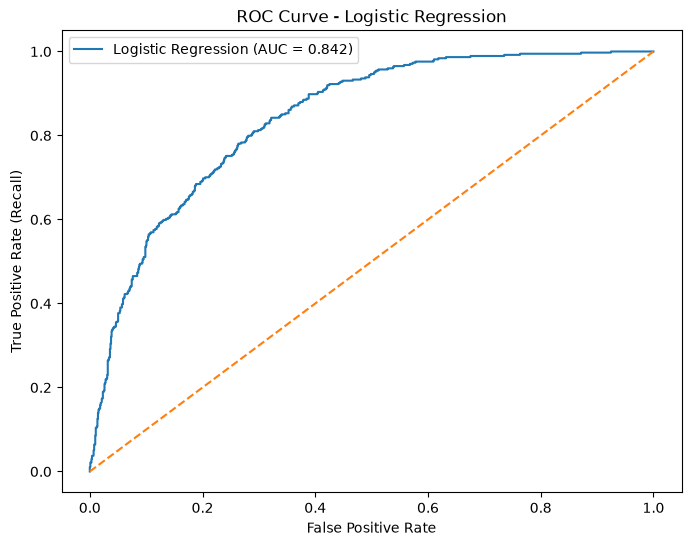

In [86]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2]

for threshold in thresholds:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1-score:  {f1:.2f}")
    print()

Threshold: 0.5
Precision: 0.66
Recall:    0.57
F1-score:  0.61

Threshold: 0.4
Precision: 0.57
Recall:    0.67
F1-score:  0.61

Threshold: 0.3
Precision: 0.52
Recall:    0.75
F1-score:  0.62

Threshold: 0.2
Precision: 0.47
Recall:    0.86
F1-score:  0.60



In [88]:
from sklearn.metrics import confusion_matrix

y_pred_03 = (y_prob_lr >= 0.3).astype(int)

cm_03 = confusion_matrix(y_test, y_pred_03)

print(cm_03)

[[774 261]
 [ 92 282]]
